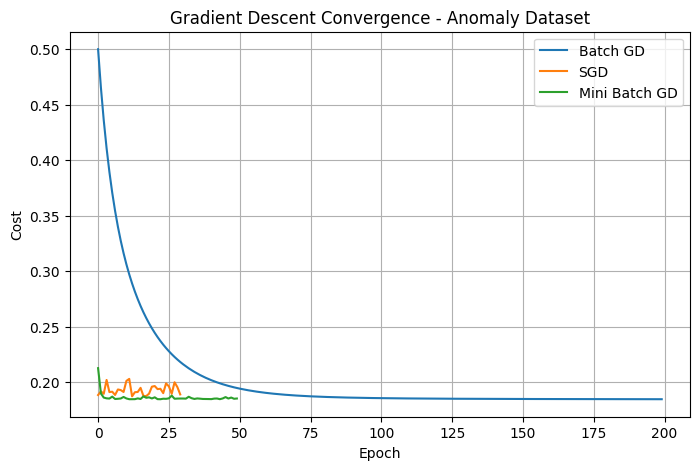

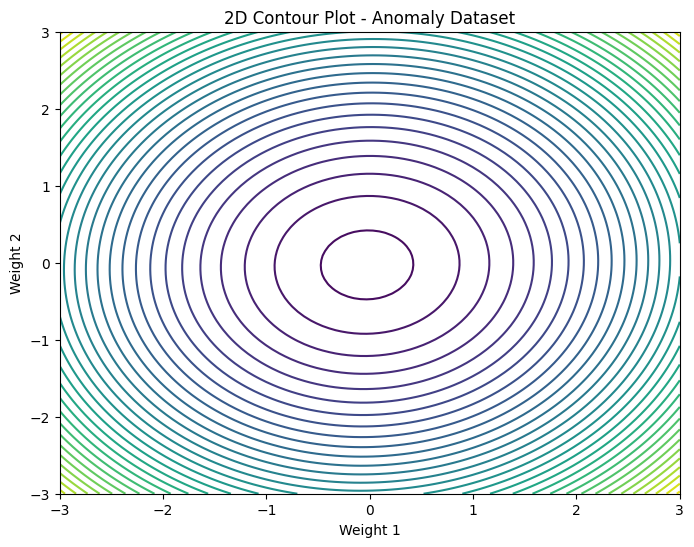

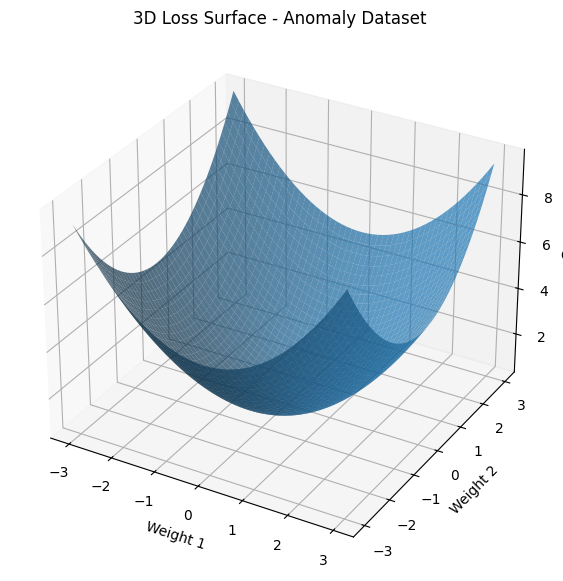

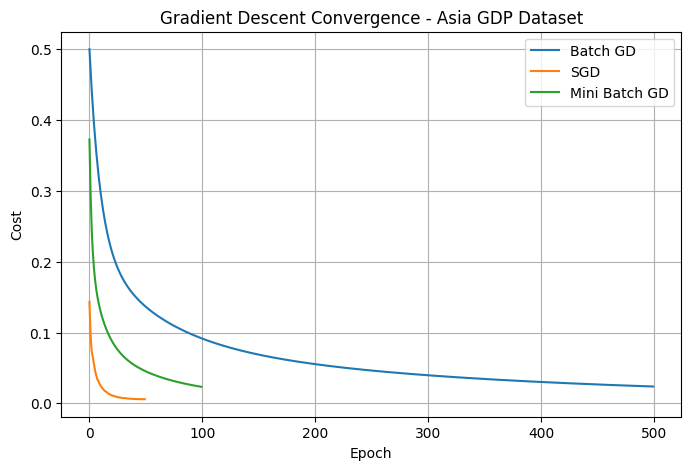

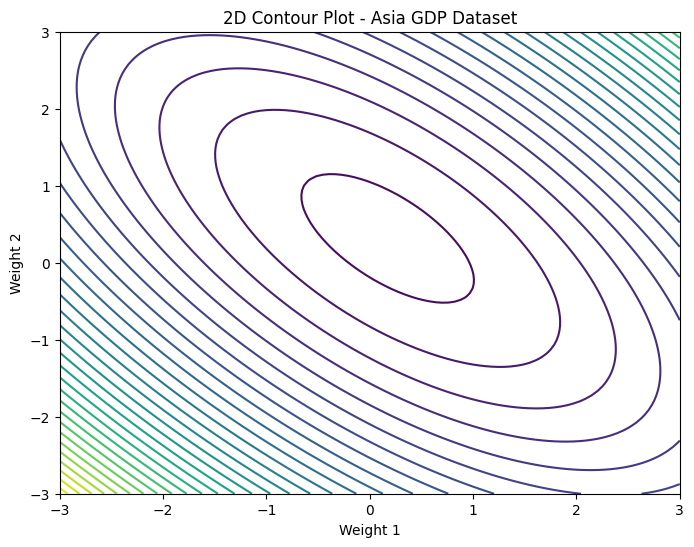

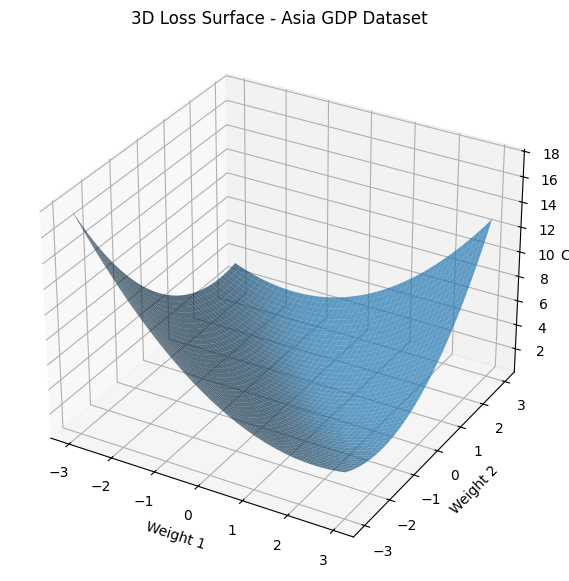

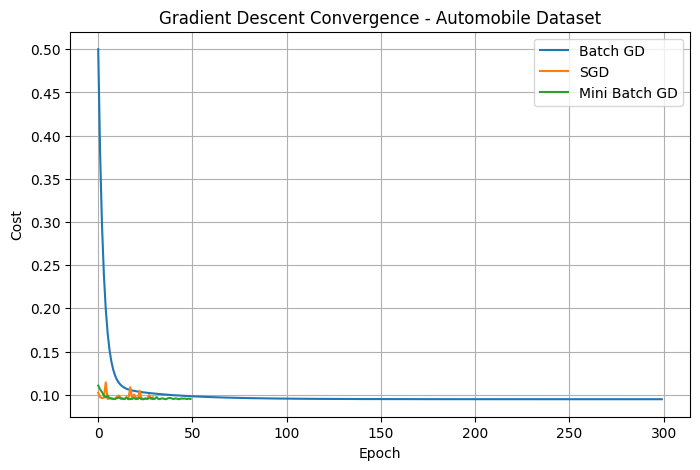

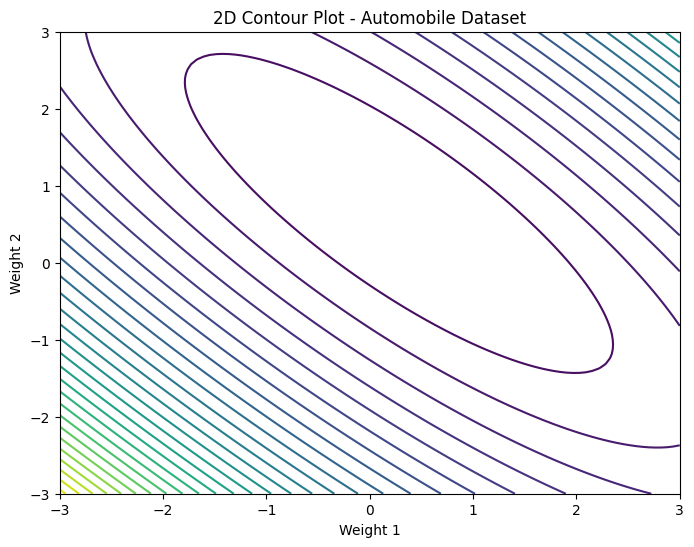

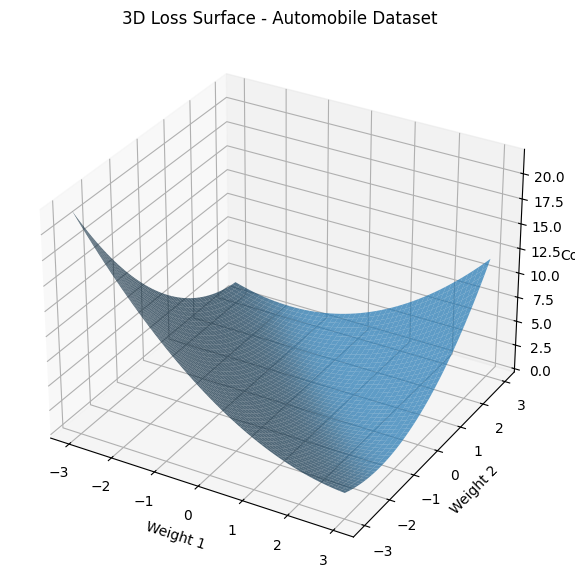

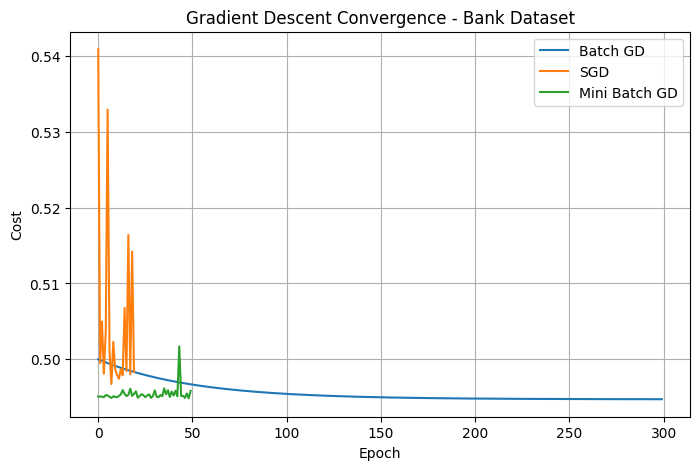

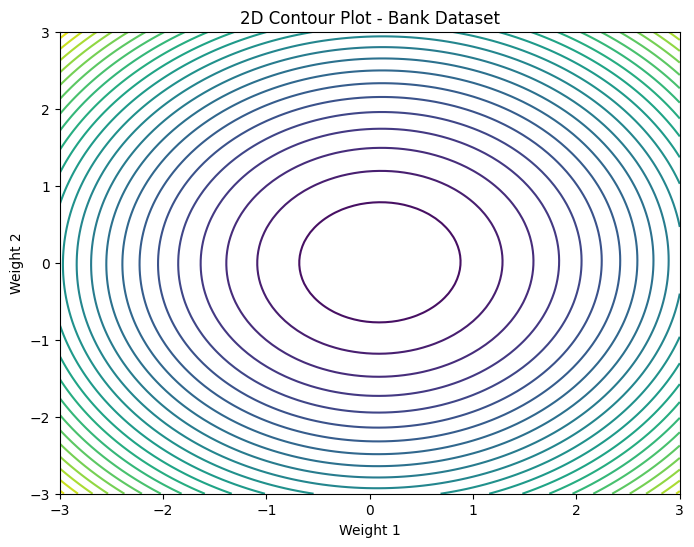

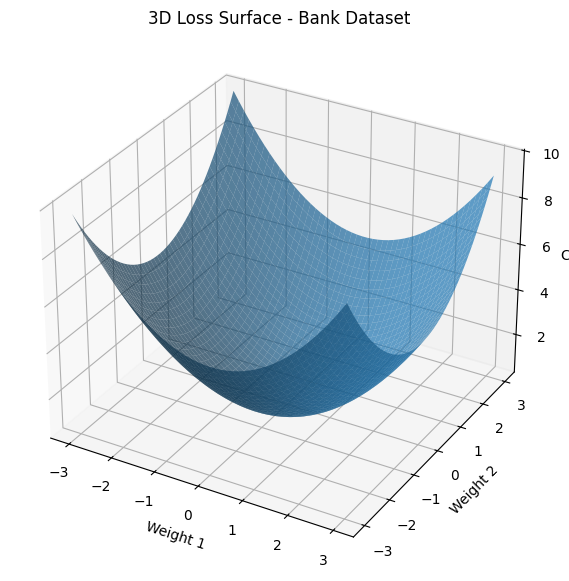

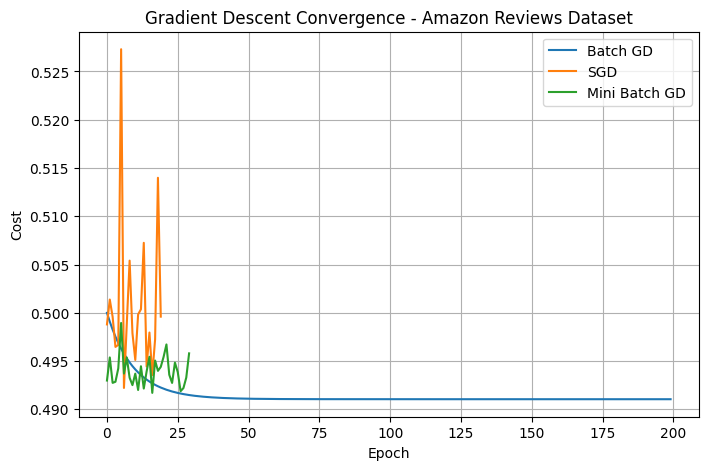

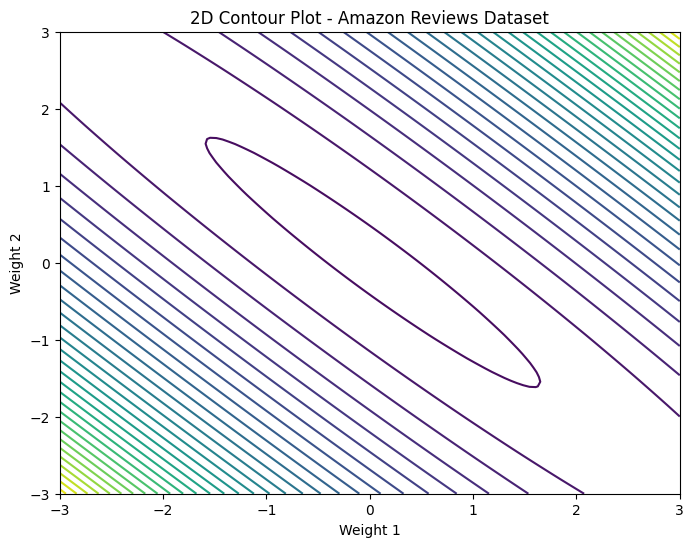

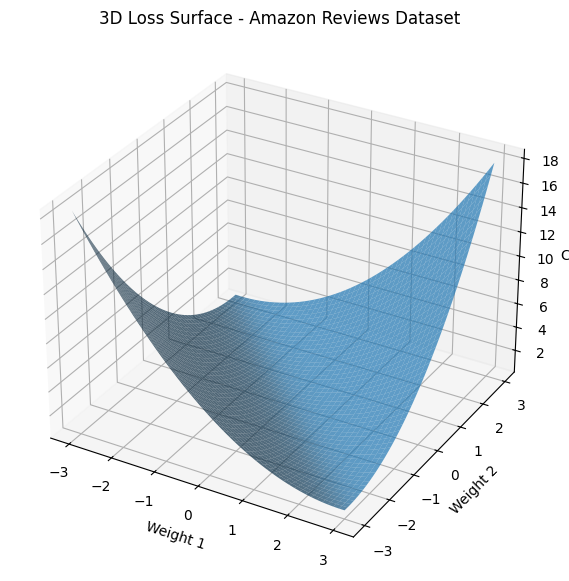

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def batch_gradient_descent(X, y, lr=0.01, epochs=1000):
    m = len(y)
    w = np.zeros(X.shape[1])
    b = 0
    cost_history = []
    for i in range(epochs):

        y_pred = np.dot(X, w) + b

        error = y_pred - y

        dw = (1/m) * np.dot(X.T, error)
        db = (1/m) * np.sum(error)

        w = w - lr * dw
        b = b - lr * db

        cost = (1/(2*m)) * np.sum(error ** 2)
        cost_history.append(cost)

    return w, b, cost_history
def stochastic_gradient_descent(X, y, lr=0.01, epochs=20):

    m = len(y)
    w = np.zeros(X.shape[1])
    b = 0
    cost_history = []
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            y_pred = np.dot(x_i, w) + b

            error = y_pred - y_i

            dw = x_i * error
            db = error

            w = w - lr * dw
            b = b - lr * db
        y_pred = np.dot(X, w) + b
        cost = np.mean((y_pred - y) ** 2) / 2

        cost_history.append(cost)

    return w, b, cost_history


def mini_batch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):

    m = len(y)

    w = np.zeros(X.shape[1])
    b = 0

    cost_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            batch_m = len(y_batch)

            y_pred = np.dot(X_batch, w) + b

            error = y_pred - y_batch

            dw = (1/batch_m) * np.dot(X_batch.T, error)
            db = (1/batch_m) * np.sum(error)

            w = w - lr * dw
            b = b - lr * db

        y_pred = np.dot(X, w) + b

        cost = np.mean((y_pred - y) ** 2) / 2
        cost_history.append(cost)

    return w, b, cost_history

def prepare_data(X, y):

    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    # remove rows containing NaN
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)

    X = X[mask]
    y = y[mask]

    # Standardization
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)

    X_std[X_std == 0] = 1

    X = (X - X_mean) / X_std

    # Standardize target also
    y_mean = y.mean()
    y_std = y.std()

    y = (y - y_mean) / y_std

    return X, y

def plot_convergence(results, dataset_name):

    plt.figure(figsize=(8,5))

    for method in results:

        plt.plot(
            results[method]["cost"],
            label=method
        )

    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.title("Gradient Descent Convergence - " + dataset_name)
    plt.legend()
    plt.grid()

    plt.show()

def contour_plot(X, y, dataset_name):

    X = X[:, :2]

    w1_values = np.linspace(-3, 3, 100)
    w2_values = np.linspace(-3, 3, 100)

    W1, W2 = np.meshgrid(w1_values, w2_values)

    Z = np.zeros(W1.shape)

    for i in range(W1.shape[0]):

        for j in range(W1.shape[1]):

            w = np.array([W1[i,j], W2[i,j]])

            prediction = np.dot(X, w)

            Z[i,j] = np.mean((prediction - y) ** 2) / 2

    plt.figure(figsize=(8,6))

    plt.contour(W1, W2, Z, levels=30)

    plt.xlabel("Weight 1")
    plt.ylabel("Weight 2")

    plt.title("2D Contour Plot - " + dataset_name)

    plt.show()

def plot_3d(X, y, dataset_name):

    X = X[:, :2]

    w1_values = np.linspace(-3, 3, 50)
    w2_values = np.linspace(-3, 3, 50)

    W1, W2 = np.meshgrid(w1_values, w2_values)

    Z = np.zeros(W1.shape)

    for i in range(W1.shape[0]):

        for j in range(W1.shape[1]):

            w = np.array([W1[i,j], W2[i,j]])

            prediction = np.dot(X, w)

            Z[i,j] = np.mean((prediction - y) ** 2) / 2

    fig = plt.figure(figsize=(9,7))

    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(W1, W2, Z, alpha=0.7)

    ax.set_xlabel("Weight 1")
    ax.set_ylabel("Weight 2")
    ax.set_zlabel("Cost")

    ax.set_title("3D Loss Surface - " + dataset_name)

    plt.show()

df = pd.read_csv("anomaly.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X, y = prepare_data(X, y)

batch_w, batch_b, batch_cost = batch_gradient_descent(
    X, y, lr=0.05, epochs=200
)

sgd_w, sgd_b, sgd_cost = stochastic_gradient_descent(
    X, y, lr=0.01, epochs=30
)

mini_w, mini_b, mini_cost = mini_batch_gradient_descent(
    X, y, lr=0.05, epochs=50, batch_size=32
)

results = {
    "Batch GD": {"cost": batch_cost},
    "SGD": {"cost": sgd_cost},
    "Mini Batch GD": {"cost": mini_cost}
}

plot_convergence(results, "Anomaly Dataset")

contour_plot(X, y, "Anomaly Dataset")
plot_3d(X, y, "Anomaly Dataset")

df = pd.read_csv("asia_gdp.csv")

X = df.iloc[:, 2:-1]
y = df.iloc[:, -1]

X, y = prepare_data(X, y)

batch_w, batch_b, batch_cost = batch_gradient_descent(
    X, y, lr=0.01, epochs=500
)

sgd_w, sgd_b, sgd_cost = stochastic_gradient_descent(
    X, y, lr=0.01, epochs=50
)

mini_w, mini_b, mini_cost = mini_batch_gradient_descent(
    X, y, lr=0.01, epochs=100, batch_size=8
)

results = {
    "Batch GD": {"cost": batch_cost},
    "SGD": {"cost": sgd_cost},
    "Mini Batch GD": {"cost": mini_cost}
}

plot_convergence(results, "Asia GDP Dataset")

contour_plot(X, y, "Asia GDP Dataset")
plot_3d(X, y, "Asia GDP Dataset")

df = pd.read_csv("automobile.csv")

# Convert numerical columns
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["engine-size"] = pd.to_numeric(df["engine-size"], errors="coerce")
df["curb-weight"] = pd.to_numeric(df["curb-weight"], errors="coerce")
df["highway-mpg"] = pd.to_numeric(df["highway-mpg"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

X = df[
    [
        "horsepower",
        "engine-size",
        "curb-weight",
        "highway-mpg"
    ]
]

y = df["price"]

X, y = prepare_data(X, y)

batch_w, batch_b, batch_cost = batch_gradient_descent(
    X, y, lr=0.05, epochs=300
)

sgd_w, sgd_b, sgd_cost = stochastic_gradient_descent(
    X, y, lr=0.01, epochs=30
)

mini_w, mini_b, mini_cost = mini_batch_gradient_descent(
    X, y, lr=0.05, epochs=50, batch_size=16
)

results = {
    "Batch GD": {"cost": batch_cost},
    "SGD": {"cost": sgd_cost},
    "Mini Batch GD": {"cost": mini_cost}
}

plot_convergence(results, "Automobile Dataset")

contour_plot(X, y, "Automobile Dataset")
plot_3d(X, y, "Automobile Dataset")

df = pd.read_csv("bank.csv")

# Take numerical columns only
X = df[
    [
        "age",
        "day",
        "duration",
        "campaign",
        "pdays",
        "previous"
    ]
]

y = df["balance"]

X, y = prepare_data(X, y)

batch_w, batch_b, batch_cost = batch_gradient_descent(
    X, y, lr=0.01, epochs=300
)

sgd_w, sgd_b, sgd_cost = stochastic_gradient_descent(
    X, y, lr=0.005, epochs=20
)

mini_w, mini_b, mini_cost = mini_batch_gradient_descent(
    X, y, lr=0.01, epochs=50, batch_size=32
)

results = {
    "Batch GD": {"cost": batch_cost},
    "SGD": {"cost": sgd_cost},
    "Mini Batch GD": {"cost": mini_cost}
}

plot_convergence(results, "Bank Dataset")

contour_plot(X, y, "Bank Dataset")
plot_3d(X, y, "Bank Dataset")
df = pd.read_csv("amazon.csv")

# Convert text into simple numerical features
df["reviewText"] = df["reviewText"].fillna("")

X = pd.DataFrame()

X["word_count"] = df["reviewText"].apply(
    lambda x: len(x.split())
)

X["character_count"] = df["reviewText"].apply(
    lambda x: len(x)
)

X["exclamation_count"] = df["reviewText"].apply(
    lambda x: x.count("!")
)

X["question_count"] = df["reviewText"].apply(
    lambda x: x.count("?")
)

X["capital_count"] = df["reviewText"].apply(
    lambda x: sum(c.isupper() for c in x)
)

y = df["Positive"]

X, y = prepare_data(X, y)

batch_w, batch_b, batch_cost = batch_gradient_descent(
    X, y, lr=0.05, epochs=200
)

sgd_w, sgd_b, sgd_cost = stochastic_gradient_descent(
    X, y, lr=0.005, epochs=20
)

mini_w, mini_b, mini_cost = mini_batch_gradient_descent(
    X, y, lr=0.05, epochs=30, batch_size=32
)

results = {
    "Batch GD": {"cost": batch_cost},
    "SGD": {"cost": sgd_cost},
    "Mini Batch GD": {"cost": mini_cost}
}

plot_convergence(results, "Amazon Reviews Dataset")

contour_plot(X, y, "Amazon Reviews Dataset")
plot_3d(X, y, "Amazon Reviews Dataset")